# 📗 Jev로 질문을 판단하고 검색 방법을 선택합니다

<strong>최초 공개일: 2026년 9월 15일.</strong> TypeSafe AI가 이날 Jev를 얼리 액세스(early access)로 출시했습니다. [공식 출시 발표](https://typesafe.ai/blog/introducing-system-one-models-and-jev)

<strong>Jev는 TypeSafe AI가 만든 판단용 모델입니다.</strong> 상황을 읽고, 미리 정한 선택지·수준·참/거짓 질문에 대한 값을 돌려줍니다. 이 값을 Python의 조건문에 넣어 다음 동작을 정할 수 있습니다.

도서 검색 질문에도 “2018년 이전 과학책”처럼 조건이 있는 질문과 “서로 다른 세 주제를 배울 책”처럼 나눠 검색해야 하는 질문이 있습니다. 이번 교안에서는 <strong>Jev가 질문을 판단하고, Python이 알맞은 질의 변환과 검색을 실행하고, LLM이 원문 근거로 답변</strong>하게 만듭니다.

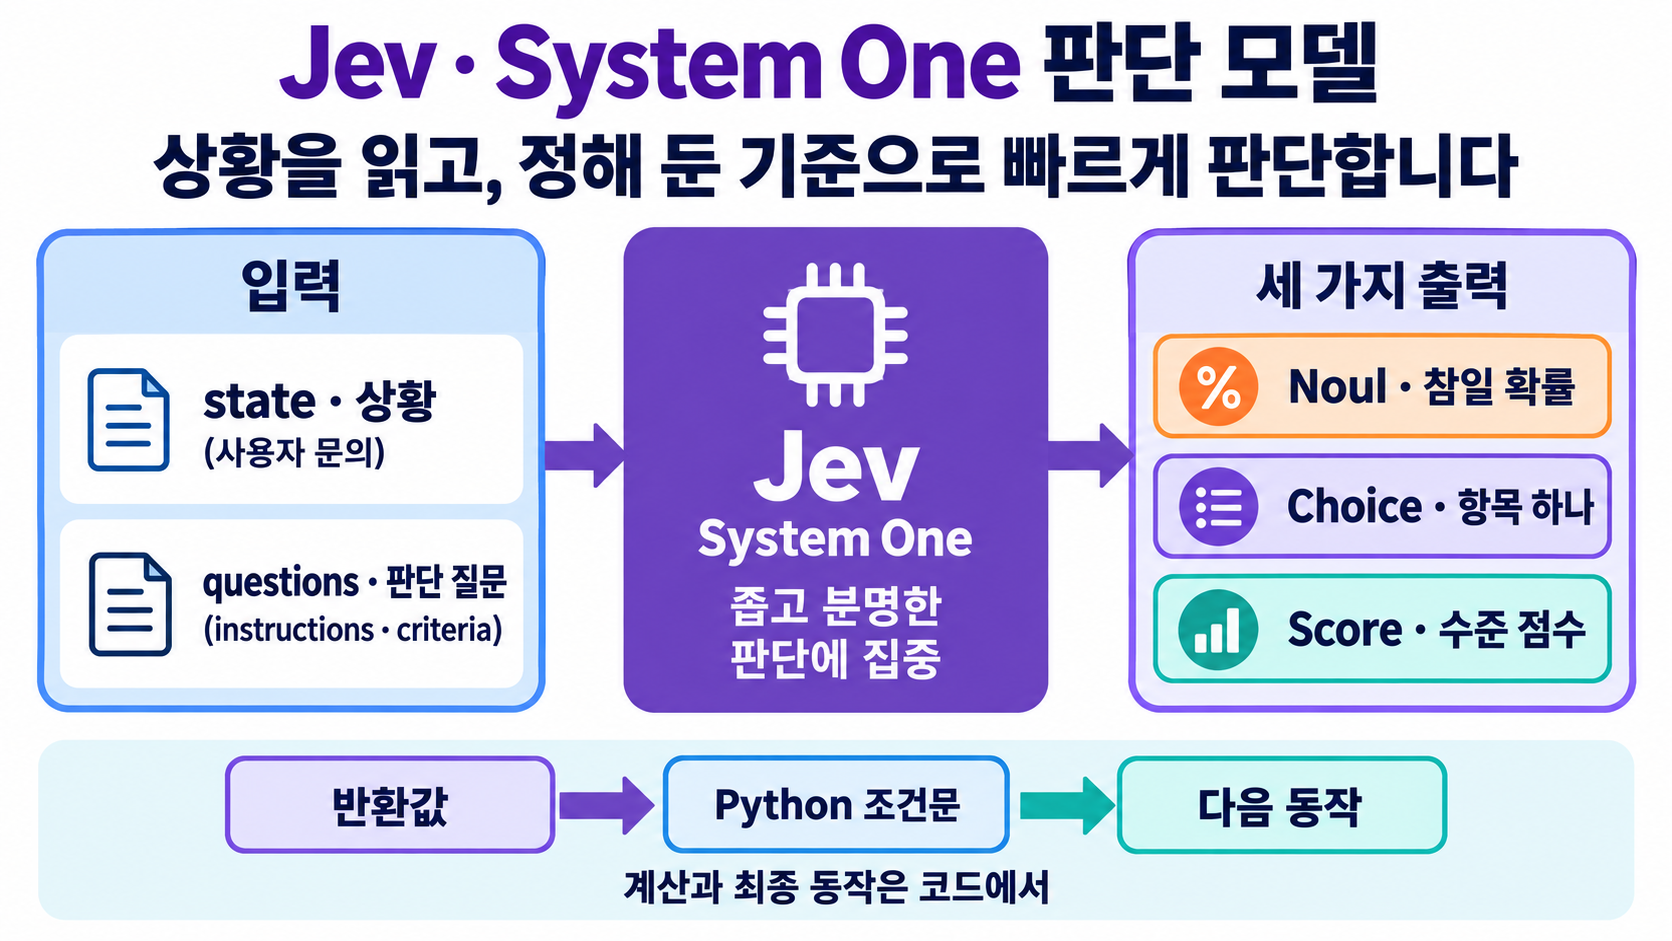

공식 문서는 이런 판단 모델을 <strong>System One 모델</strong>이라고 부릅니다. 사람이 빠르게 구분할 만한 좁은 판단을 맡긴다는 의미로 이해하면 됩니다. 설명 작성·복잡한 계산까지 맡기기보다는, 판단 하나씩 분리하고 계산과 최종 동작은 코드에 둡니다. [Jev 소개](https://docs.typesafe.ai/introduction) · [공식 한계 안내](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

이 교안은 설명과 실행 가능한 시연으로 구성되어 있습니다. 위에서부터 실행하며 결과를 읽습니다.


## 오늘의 목표

- [ ] Noul·Choice·Score의 반환값을 구분할 수 있습니다.
- [ ] 상황과 판단 기준을 작성해 공식 SDK로 Jev를 호출할 수 있습니다.
- [ ] 쿼리에 따라 교안 02의 질의 변환 방법 하나를 선택하고 실제 RAG 답변을 만들 수 있습니다.

## ⏪ 복습: 교안 02의 다섯 질의 변환

교안 02에서는 Self-Query·HyDE·Multi-Query·Step-back·Decomposition을 직접 골라 실행했습니다. 이번에는 <strong>사용자 질문 → Jev의 방법 선택 → 해당 변환 실행 → 하이브리드 검색 → 원문 기반 답변</strong>으로 연결합니다. 교안 02의 가상 장서 10권과 BM25·Dense·RRF 설정을 그대로 씁니다.


## 1. Jev에는 무엇을 보내고 무엇을 받을까요?

Jev에게 주는 입력은 <strong>판단할 상황과 판단 기준</strong>입니다. 예를 들어 담당 창구를 고른다면 고객의 문의가 상황이고, 각 창구가 맡는 업무가 기준입니다.

| 입력 | 역할 | 이 교안의 예 |
|---|---|---|
| `state` | 판단할 내용 | 사용자의 도서관 질문 |
| `questions` | 질문 이름과 질문 객체를 모은 딕셔너리 | `topic`, `breadth`, `needs_documents` |
| `model` | 사용할 Jev 모델 | `jev-1.13.0` |

### state에 판단할 내용과 참고 정보를 담습니다

`state`에는 <strong>모델이 판단할 내용과 그 판단에 필요한 참고 정보</strong>를 넣습니다. 문의 문장 하나라면 문자열로, 여러 정보를 함께 전달하려면 JSON으로 표현 가능한 딕셔너리나 리스트로 작성합니다.

| 형식 | 담을 수 있는 내용 |
|---|---|
| 문자열 | 사용자 문의, 검토할 문서 본문 |
| 딕셔너리 | 문의와 관련 정책, 사용자 상황, 서비스 범위처럼 이름으로 구분할 정보 |
| 리스트 | 대화 메시지나 관련 기록의 목록 |

딕셔너리 안에 딕셔너리나 리스트를 넣을 수도 있습니다. 다음은 문의와 참고 정보를 함께 담은 예입니다.

```python
state = {
    "user_query": "그중에서 초보자가 볼 책을 찾아 주세요.",
    "conversation": [
        "사용자: 파이썬 데이터 분석 책을 찾고 있어요."
    ],
    "service_scope": "도서 목록에서 관련 책 찾기",
    "user_context": {
        "experience": "파이썬 기초 문법을 배운 상태"
    },
}
```

<strong>`user_query`, `conversation`, `service_scope`, `user_context`는 작성자가 직접 정한 키입니다.</strong> API가 요구하는 필수 키가 아니므로, 판단할 작업에 맞춰 이름과 내용을 정합니다. 이 예제에서 `service_scope`는 서비스가 처리하는 범위를, `conversation`은 “그중에서”가 가리키는 이전 대화를 알려 줍니다. 관련 문서, 업무 정책, 현재 처리 상태도 판단에 필요하면 추가할 수 있습니다. [State 공식 문서](https://docs.typesafe.ai/concepts/state)

### questions에 판단할 질문과 기준을 적습니다

`state`에 담은 내용을 보고 <strong>무엇을 판단할지</strong>는 `questions`의 질문 객체에 적습니다. `instructions`에는 판단할 질문을, `Choice`·`Score`의 `criteria`에는 선택지나 수준별 기준을 적습니다.

`questions` 안의 `topic` 같은 이름은 <strong>응답을 다시 찾는 키</strong>입니다. 모델은 이 키를 보지 않으므로 판단할 질문은 `instructions`에 적습니다. [질문 구조](https://docs.typesafe.ai/primitives/choice)

### Noul·Choice·Score로 판단 결과를 받습니다

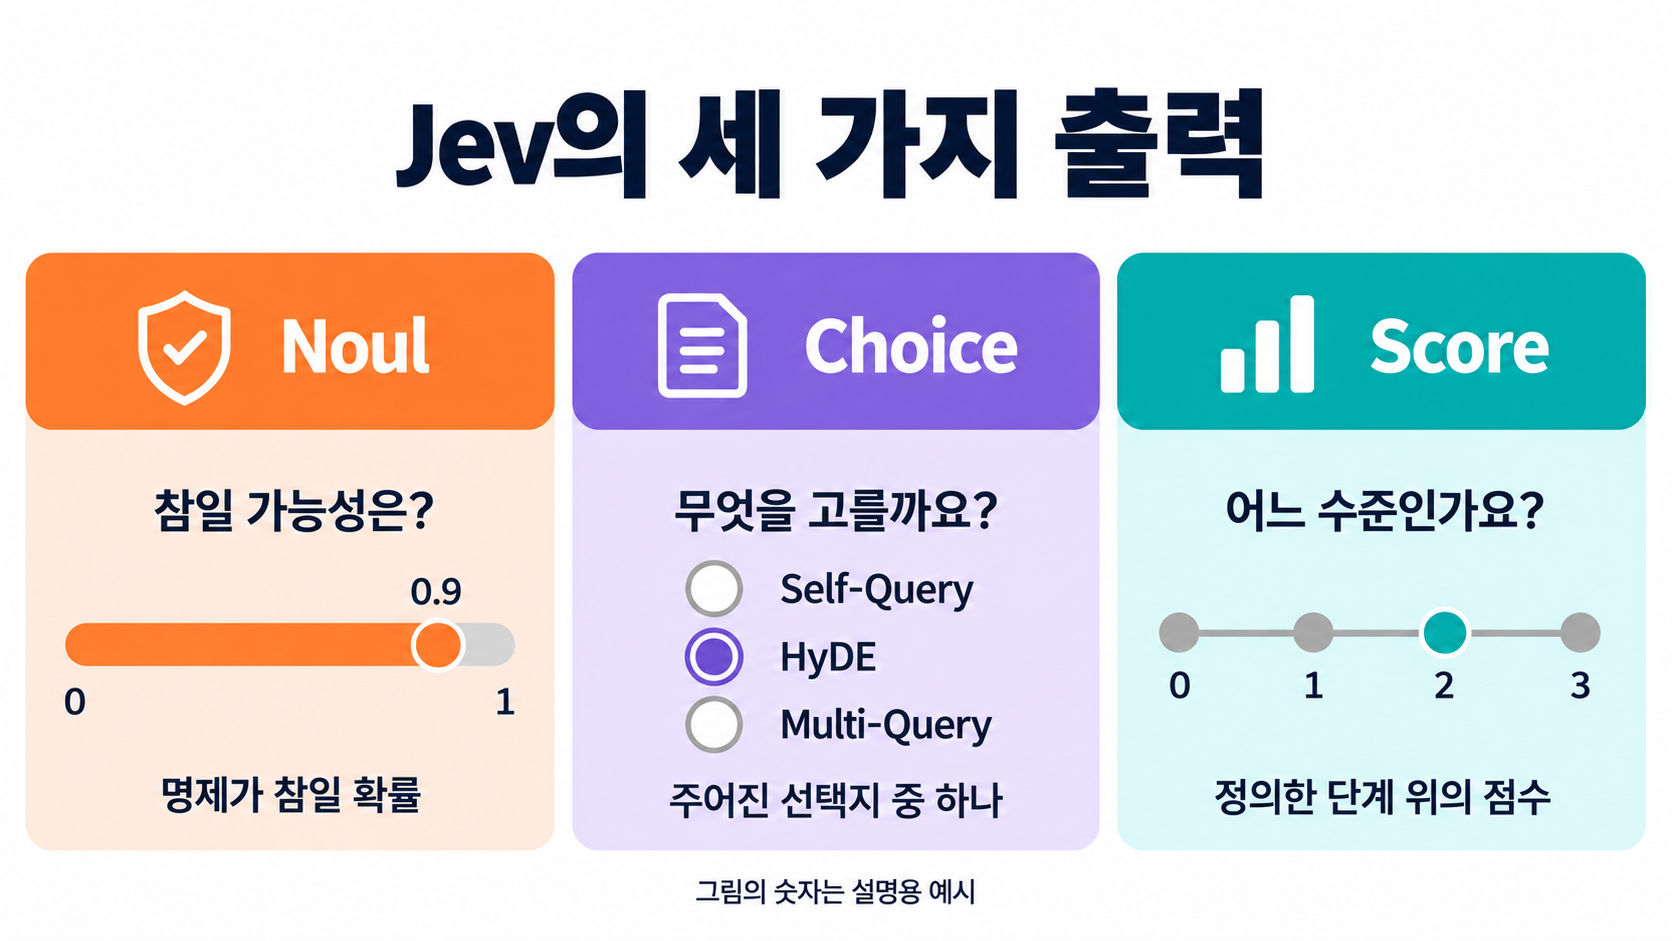

| 출력 종류 | 물어볼 내용 | 먼저 읽을 값 | 함께 볼 값 |
|---|---|---|---|
| `Noul` | 이 조건이 참인가요? | `noul` | 별도 `confidence` 없음 |
| `Choice` | 어떤 항목인가요? | `choice` | `probabilities`, `confidence` |
| `Score` | 어느 수준인가요? | `score` | `legend`, `probabilities`, `confidence` |

타입이 정해져 있어도 <strong>판단 내용까지 항상 정답인 것은 아닙니다.</strong> 선택지를 모호하게 쓰거나 필요한 상황을 주지 않으면 잘못 판단할 수 있습니다. [출력 종류](https://docs.typesafe.ai/primitives)


### 설치와 키 준비

공식 SDK `typesafe-sdk==0.7.1`(import 이름: `typesafe_sdk`)은 저장소 최상위 `uv sync`로 이미 설치됩니다.

같은 폴더의 `.env`에 `TYPESAFE_API_KEY`(Jev)와 `OPENAI_API_KEY`(질의 변환·임베딩·답변)를 넣습니다. 기본 모델은 `jev-1.13.0`이며 `TYPESAFE_MODEL`로 바꿀 수 있습니다.

[SDK 문서](https://docs.typesafe.ai/sdk/python) · [키 발급](https://console.typesafe.ai/keys)


In [ ]:
# 파일과 표는 앞 교안 방식으로 다루고, 판단에는 TypeSafe 공식 SDK를 사용합니다.
import json
import os
from pathlib import Path

import pandas as pd
from dotenv import find_dotenv, load_dotenv
from typesafe_sdk import Choice, Noul, Score, TypeSafeClient


In [ ]:
# data는 배포 자료, output은 이 노트북을 실행해서 만든 결과입니다.
material_dir = Path(".")
data_dir = material_dir / "data"
output_dir = material_dir / "output"
output_dir.mkdir(exist_ok=True)


def read_json(name):
    """data 폴더의 JSON 파일을 목록 또는 딕셔너리로 읽습니다."""
    return json.loads((data_dir / name).read_text(encoding="utf-8"))


def save_json(name, value):
    """처리 결과를 output 폴더에 한글을 유지해 저장합니다."""
    (output_dir / name).write_text(
        json.dumps(value, ensure_ascii=False, indent=2), encoding="utf-8"
    )


In [ ]:
# 키 값을 출력하지 않고, 필요한 키가 있는지만 확인합니다.
load_dotenv(find_dotenv(usecwd=True))
if not os.getenv("TYPESAFE_API_KEY"):
    raise ValueError(".env에 TYPESAFE_API_KEY를 설정한 뒤 이 셀부터 다시 실행하세요.")

jev_model = os.getenv("TYPESAFE_MODEL", "jev-1.13.0")
jev_client = TypeSafeClient(timeout=30.0)
print("Jev 모델:", jev_model)



## 2. Noul로 참일 가능성을 판단합니다

`Noul`은 “이 문의는 도서관 규정을 확인해야 답할 수 있나요?”처럼 <strong>예/아니요로 답할 수 있는 질문</strong>에 씁니다. 반환값 `noul`은 <strong>예일 확률</strong>입니다.

- 1에 가까우면 “예” 쪽입니다.
- 0에 가까우면 “아니요” 쪽입니다. 확신이 낮다는 뜻이 아닙니다.
- 0.5 근처라면 어느 쪽인지 애매합니다.

최종 통과·보류 기준은 코드에서 정합니다. 아래의 0.2와 0.8은 <strong>수업용 정책</strong>이며, 모든 작업에 통하는 공식 기준은 아닙니다. [Noul 문서](https://docs.typesafe.ai/primitives/noul)


In [ ]:
# 세 출력의 기초 예제에서 함께 사용할 도서관 문의입니다.
basic_query = "도서관 그룹 학습실은 몇 명부터 이용할 수 있나요?"

# 이 질문은 규정 조회의 필요성만 묻습니다. 실제 근거가 있는지는 검색 후 확인합니다.
needs_documents_question = Noul(
    instructions="사용자 문의에 답하려면 도서관의 자료 또는 공간 이용 규정을 확인해야 하나요?",
)
noul_response = jev_client.system_one(
    model=jev_model,
    state=basic_query,
    questions={"needs_documents": needs_documents_question},
)
# SDK가 반환한 전체 응답을 JSON 형태로 먼저 확인합니다.
print("Jev 응답 전체:")
print(noul_response.model_dump_json(indent=2))

needs_documents = noul_response.answers["needs_documents"].noul
print("규정 조회가 필요할 확률:", needs_documents)


In [ ]:
# 확률을 Python의 bool로 바로 바꾸면 0.1도 True가 되므로 범위를 비교합니다.
if needs_documents >= 0.8:
    print("정책 판단: 도서관 규정을 조회합니다.")
elif needs_documents <= 0.2:
    print("정책 판단: 규정 조회가 필요한 문의로 보지 않습니다.")
else:
    print("정책 판단: 무엇을 확인하려는지 더 구체적으로 묻습니다.")

## 3. Choice로 정해진 항목 중 하나를 선택합니다

`Choice`는 객관식 질문과 비슷합니다. 선택지에 순위는 없습니다. “대출”이 “공간”보다 높은 점수라는 뜻이 아니라, <strong>서로 다른 종류</strong>입니다.

`criteria`는 <strong>이름: 설명</strong> 딕셔너리로 씁니다. 설명을 구분하기 쉽게 작성하고, 다루지 않는 문의를 억지로 넣지 않도록 `other`도 둡니다. [Choice 문서](https://docs.typesafe.ai/primitives/choice)


In [ ]:
# 선택지 이름은 코드에서 쓰고, 설명은 주제의 경계를 모델에 알려 줍니다.
topic_question = Choice(
    instructions="사용자의 도서관 문의가 주로 다루는 주제는 무엇인가요?",
    criteria={
        "loan": "종이책 대출 권수, 기간, 연장, 연체 조건",
        "return": "도서 반납 장소, 반납함, 파손 또는 분실",
        "space": "열람실 또는 그룹 학습실의 예약과 이용 조건",
        "digital": "전자책, 학술 데이터베이스, 교외 인증",
        "other": "여러 주제가 섞였거나 위 주제로 분류할 수 없는 문의",
    },
)


In [ ]:
# 이 호출에서 실제 Jev 요청이 발생합니다. 'topic'은 응답을 찾을 키입니다.
choice_response = jev_client.system_one(
    model=jev_model,
    state=basic_query,
    questions={"topic": topic_question},
)
# SDK가 반환한 전체 응답을 JSON 형태로 먼저 확인합니다.
print("Jev 응답 전체:")
print(choice_response.model_dump_json(indent=2))

topic = choice_response.answers["topic"]
print("선택:", topic.choice)
print("선택의 confidence:", topic.confidence)
display(pd.DataFrame(topic.probabilities.items(), columns=["option", "probability"]))


### Choice 결과는 이렇게 읽습니다

학습실 이용 조건을 묻는 문의가 `space`로 분류되는지 확인합니다. `choice`는 선택된 주제 이름이고, `probabilities`는 주제별 확률입니다.

`confidence`는 확률 분포가 얼마나 한쪽으로 모였는지 요약한 값입니다. <strong>선택된 항목의 확률과 같은 값으로 취급하거나, 0.9이면 이 답이 반드시 90% 정확하다고 해석하지 않습니다.</strong> 응답의 필드 둘을 구분해서 읽습니다. [Confidence 문서](https://docs.typesafe.ai/confidence)


## 4. Score로 순서가 있는 수준을 판단합니다

`Score`는 우리가 정한 기준에 따라 수준을 점수로 나타냅니다. 이번 예제는 <strong>답변을 만들 때 여러 내용을 함께 정리해야 하는 정도</strong>를 판단합니다.

| 수준 점수 | 답변에 필요한 내용 | 질문 예시 |
|---|---|---|
| 0점 | 사실 하나 | “그룹 학습실은 몇 명부터 이용할 수 있나요?” |
| 1점 | 규칙 하나의 조건과 예외 | “그룹 학습실 예약 조건과 예외는 무엇인가요?” |
| 2점 | 한 서비스의 여러 규칙 | “그룹 학습실의 예약·입실·퇴실 규칙을 정리해 주세요.” |
| 3점 | 여러 서비스의 규칙 | “대출·반납·학습실·전자 자료의 이용 규칙을 모두 정리해 주세요.” |

<strong>0점에 가까우면 한 가지 사실을 확인하면 되고, 3점에 가까우면 여러 서비스의 규칙을 함께 살펴야 합니다.</strong> 이 점수의 의미는 위 기준으로 정한 것입니다.

`criteria`가 네 개라면 수준 번호는 <strong>0·1·2·3</strong>, 점수 범위는 <strong>0~3</strong>입니다. 점수는 각 수준 번호에 그 확률을 곱해 더한 값이라 소수가 될 수 있습니다. 설명용으로 2수준의 확률이 0.2, 3수준의 확률이 0.8이라면 점수는 2.8입니다. 실제 API 출력은 아래에서 확인합니다. [Score 문서](https://docs.typesafe.ai/primitives/score)

표의 열은 다음처럼 읽습니다. <strong>확률과 수준 점수는 서로 다른 값입니다.</strong>

| 열 | 의미 |
|---|---|
| `level_score` | 기준의 순서에 따라 미리 정해진 수준 점수: 0·1·2·3 |
| `description` | 그 수준에 해당하는 기준 설명 |
| `probability` | 모델이 질문을 해당 수준으로 판단할 확률: 0~1 |
| `weighted_contribution` | 수준 점수 × 확률. 이 열을 모두 더하면 최종 Score |

수준별 점수를 모델이 각각 새로 매기는 것이 아닙니다. 모델은 각 수준의 확률을 반환하며, 그 확률을 가중치로 사용해 최종 점수를 계산합니다.


In [ ]:
# 리스트 순서가 수준 번호를 정합니다. 숫자 크기의 의미는 우리가 정의합니다.
breadth_question = Score(
    instructions="사용자 질문에 답하려면 어느 범위의 정보를 모아야 하나요?",
    criteria=[
        "특정 사실 하나: 인원, 기간, 장소 등 한 가지 값을 확인하면 됨",
        "규칙 하나: 그 규칙의 적용 조건이나 예외까지 함께 확인해야 함",
        "같은 주제의 여러 규칙: 한 서비스의 절차나 규칙을 함께 정리해야 함",
        "서로 다른 여러 주제: 대출, 반납, 공간 등 전반을 종합해야 함",
    ],
)
score_response = jev_client.system_one(
    model=jev_model,
    state="도서관의 대출, 반납, 공간, 전자 자료 이용 규칙을 한 번에 정리해 주세요.",
    questions={"breadth": breadth_question},
)
# SDK가 반환한 전체 응답을 JSON 형태로 먼저 확인합니다.
print("Jev 응답 전체:")
print(score_response.model_dump_json(indent=2))

breadth = score_response.answers["breadth"]
print("여러 내용을 함께 정리해야 하는 정도:", breadth.score, "/ 0~3점")
print("기준: 0=사실 하나, 1=규칙 하나와 조건·예외, 2=한 서비스의 여러 규칙, 3=여러 서비스의 규칙")
print("점수의 confidence:", breadth.confidence)
# 각 수준의 고정 점수와 모델이 반환한 확률을 구분합니다.
score_table = pd.DataFrame([
    {
        "level_score": int(level),
        "description": description,
        "probability": breadth.probabilities[level],
        "weighted_contribution": int(level) * breadth.probabilities[level],
    }
    for level, description in breadth.legend.items()
])
print("수준별 점수 · 확률 · 최종 점수에 더해지는 값:")
display(score_table)


In [ ]:
# 점수의 의미를 확인하는 계산입니다. 이 셀은 모델을 호출하지 않습니다.
weighted_score = sum(
    int(level) * probability
    for level, probability in breadth.probabilities.items()
)
print("API 점수:", breadth.score)
print("수준별 확률로 계산한 점수:", round(weighted_score, 4))


점수가 높다는 것은 답변하려면 <strong>더 다양한 규칙과 주제를 함께 확인해야 한다</strong>는 뜻입니다. 답변 품질이나 정답 확률을 측정한 값이 아닙니다. 같은 2점이라도 어떤 수준 설명을 주었는지에 따라 뜻이 달라지므로 `legend`와 함께 읽습니다.

`score`와 함께 `probabilities`를 확인하면 각 수준에 부여된 확률을 볼 수 있습니다. 앞의 계산 예에서 2.8점은 2점에 확률 0.2, 3점에 확률 0.8을 곱해 더한 결과입니다.


### 세 출력의 해석 방법

| 값 | 바르게 읽는 방법 |
|---|---|
| `Choice`의 `choice` | 선택지 중 확률이 가장 높은 항목입니다. 선택지 사이에 순위나 점수의 높고 낮음은 없습니다. |
| `Score`의 `score` | 각 수준 번호에 해당 확률을 곱해 더한 값입니다. 값이 클수록 `criteria`의 뒤쪽 수준에 가깝습니다. 점수의 의미는 `legend`의 수준 설명과 함께 읽습니다. |
| `Noul`의 `noul` | 질문에 대한 답이 “예”일 확률입니다. 1에 가까우면 “예”, 0에 가까우면 “아니요”, 0.5에 가까우면 두 답의 확률이 비슷합니다. |
| `Choice`·`Score`의 `confidence` | 선택지 또는 수준의 확률 분포에서 계산한 0~1 값입니다. 확률이 하나에 집중될수록 높고, 여러 항목에 분산될수록 낮습니다. |

`score`가 높다는 뜻은 정한 수준 기준에 따라 달라집니다. 예를 들어 심각도를 평가한다면 높은 점수는 더 심각한 상태를 뜻합니다. `confidence`는 선택된 항목의 확률이나 답변의 정답률과 구분해서 읽습니다.



## 5. 독립적인 질문은 한 요청에 묶습니다

같은 사용자 문의에 대해 문의 주제·여러 내용을 함께 정리해야 하는 정도·규정 조회 필요 여부를 함께 묻습니다. `questions`의 각 항목은 <strong>같은 state를 독립적으로 읽습니다.</strong> 앞 질문의 결과를 다음 질문이 받아 처리하는 순서가 아닙니다.

“topic이 space면 답해라”처럼 다른 질문의 반환값에 의존하는 지시를 넣지 않습니다. 응답이 모두 온 뒤 Python에서 값을 조합합니다. [여러 질문 호출](https://docs.typesafe.ai/primitives)


In [ ]:
# 이미 만든 세 질문 객체를 같은 요청에 넣어 실제 호출 수를 줄입니다.
batch_response = jev_client.system_one(
    model=jev_model,
    state=basic_query,
    questions={
        "topic": topic_question,
        "breadth": breadth_question,
        "needs_documents": needs_documents_question,
    },
)
# SDK가 반환한 전체 응답을 JSON 형태로 먼저 확인합니다.
print("Jev 응답 전체:")
print(batch_response.model_dump_json(indent=2))

print("Choice:", batch_response.answers["topic"].choice)
print("Score:", batch_response.answers["breadth"].score)
print("Noul:", batch_response.answers["needs_documents"].noul)
print("실제 응답 모델:", batch_response.model)
print("입력 토큰:", batch_response.usage.input_tokens)


### ✅ 바로 확인 퀴즈

<strong>1. 검색 방법 하나를 선택할 때 Choice와 Score 중 무엇이 직접적인가요?</strong>

<details><summary>정답 보기</summary><p>Choice입니다. 방법은 순서 없는 종류입니다. Score는 정의한 수준 위의 점수입니다.</p></details>

<strong>2. Noul이 0.05이면 판단이 애매하다는 뜻인가요?</strong>

<details><summary>정답 보기</summary><p>아니요. 예일 확률이 낮아 아니요 쪽입니다. 예와 아니요가 비슷한 값은 0.5 근처입니다.</p></details>

<strong>3. 한 요청의 두 번째 질문이 첫 번째 질문의 답을 읽을 수 있나요?</strong>

<details><summary>정답 보기</summary><p>아니요. 각 질문은 같은 state를 독립적으로 평가합니다. 답의 조합은 호출 후 코드에서 합니다.</p></details>


## 6. 응용: Jev가 교안 02의 방법을 골라 RAG를 실행합니다

기초 예제는 도서관 문의의 성격을 판단했습니다. 응용에서는 <strong>장서 검색 질문에 맞는 질의 변환 방법</strong>을 판단합니다. 같은 질문에 모든 방법을 실행하지 않고, 선택된 경로 하나만 실행합니다.

| 선택지 | 주로 필요한 질문 | 실제로 바꾸는 검색 입력 |
|---|---|---|
| `self_query` | 분류·출판 연도 조건이 명시됨 | 본문 검색어와 공통 메타데이터 필터 |
| `hyde` | 용어를 몰라 상황으로 설명함 | Dense에 넣을 가상 소개문(BM25는 원질문) |
| `multi_query` | 같은 정보 요구를 여러 표현으로 찾음 | 원질문과 같은 뜻의 검색 질문 3개 |
| `step_back` | 구체적 사례의 배경 원리를 이해하려 함 | 원질문과 기초 개념 질문 |
| `decomposition` | 서로 다른 정보 요구를 각각 찾음 | 독립적으로 검색할 하위 질문 2~3개 |
| `clarify` | 장서 검색 범위 밖이거나 대상이 불명확함 | 검색을 멈추고 질문을 확인 |

한 질문에는 여러 방법이 가능할 수 있습니다. 이 교안은 <strong>명시된 필터 → 독립 정보 요구 → 배경 원리 → 용어 부족 → 같은 뜻의 표현 확장</strong> 순으로 우선순위를 정합니다. Jev가 선택한 방법이 위 기준에 맞는지 확인하고, 검색된 원문에 질문에 답할 내용이 있는지 확인합니다.

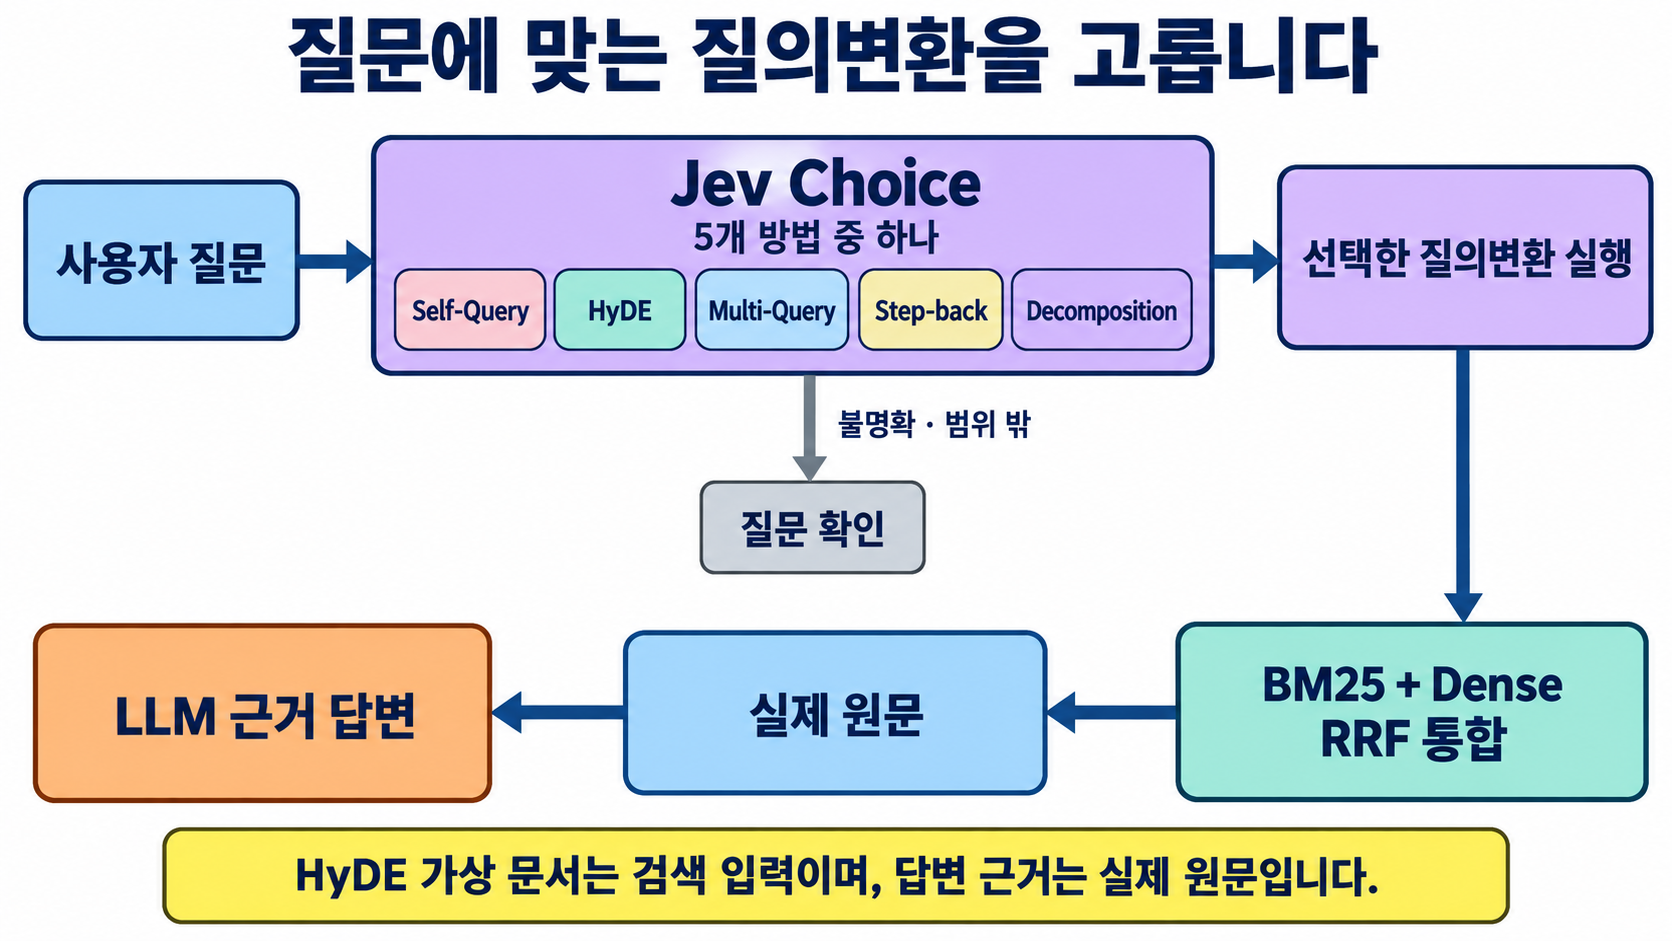


### 6-1. 교안 02의 구현을 모듈에서 가져옵니다

질의 변환 프롬프트·필터·하이브리드 검색 코드는 같은 폴더의 [query_transforms.py](query_transforms.py)에 있습니다. 교안 02에서 배운 다섯 방법을 함수로 재사용합니다. 이 교안에서는 <strong>Jev의 판단을 실제 실행으로 연결하는 흐름</strong>에 집중합니다.

- `prepare_retrieval`: 장서 적재, BM25·Dense·RRF, 다섯 변환 체인을 준비합니다.
- `retrieve`: 선택한 방법 하나를 실행해 원문 목록과 검색 입력 기록을 반환합니다.
- `format_context`: 검색된 실제 원문을 답변 문맥으로 만듭니다.

`data/demo_docs.json`은 교안 02와 같은 수업용 가상 장서 10권입니다. `query_transforms.py`를 이 노트북과 같은 폴더에 둡니다.


In [ ]:
# 이미 배운 질의 변환·검색 구현은 모듈에서 가져옵니다.
from query_transforms import prepare_retrieval, retrieve, format_context
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


In [ ]:
# data와 read_json은 앞에서 준비한 것을 그대로 사용합니다.
records = read_json("demo_docs.json")
display(pd.DataFrame(records)[["doc_id", "title", "metadata"]])


In [ ]:
# 연결 설정만 준비합니다. 실제 요청은 적재·검색·invoke에서 발생합니다.
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("응용 실행에는 .env의 OPENAI_API_KEY가 필요합니다.")
llm = ChatOpenAI(
    model=os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna"), use_responses_api=True,
)
embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-large", dimensions=768,
    check_embedding_ctx_length=False,  # 준비한 짧은 원문을 자동 길이 검사·분할 없이 보냅니다.
)


검색기는 한 번 준비하고 모든 질문에서 재사용합니다. 아래 호출은 수업용 컬렉션을 다시 만들고 원문 10권을 실제로 임베딩합니다. 교안 02와 같은 <strong>TOP_K=3, BM25·Dense 가중치 0.5·0.5, RRF의 c=60</strong>을 사용합니다. 변환 체인을 준비하는 것만으로는 GPT를 호출하지 않습니다.


In [ ]:
# 반환된 retrieval에는 이후 질문들이 함께 사용할 검색기와 변환 체인이 들어 있습니다.
TOP_K = 3
retrieval = prepare_retrieval(records, llm, embedding_model, k=TOP_K)
print("검색 준비 완료. 원문 수:", retrieval["document_count"])


### 6-2. Jev의 선택과 실행 기준을 정합니다

`state`에 원질문과 서비스 범위를 보내고, `criteria`에 각 질의 변환 방법을 선택할 기준을 적습니다. Jev는 <strong>질문에 명시된 조건과 필요한 정보의 형태</strong>로 변환 방법을 판단합니다.

아래 `state`의 `user_query`와 `service_scope`는 이 교안에서 정한 키입니다. `user_query`는 원질문이고, `service_scope`는 서비스가 처리하는 범위입니다. Jev는 이 범위를 참고해 도서 검색과 무관한 질문을 `clarify`로 분류할지 판단합니다. `service_scope` 자체가 검색기의 필터를 설정하지는 않습니다.

선택이 `clarify`이거나 confidence가 0.6보다 작으면 보류합니다. 0.6은 <strong>수업용 정책</strong>이며 공식 권장값이나 정답 보장 기준이 아닙니다.


In [ ]:
route_question = Choice(
    instructions=(
        "도서 검색 질문에 적용할 질의 변환 방법 하나를 고르세요. "
        "도서 검색과 무관하거나 대상을 알 수 없으면 clarify입니다. "
        "여러 기준이 겹치면 명시된 메타데이터 조건, 독립 정보 요구, "
        "배경 원리, 용어 부족, 같은 뜻의 표현 확장 순으로 우선합니다."
    ),
    criteria={
        "self_query": "분류(category)나 출판 연도(year)를 제한하는 명시적 조건이 있는 도서 검색",
        "decomposition": "서로 다른 주제나 독립 정보 요구 2~3개를 각각 배울 책을 찾음. 같은 개념의 다른 표현은 제외",
        "step_back": "구체적인 사례나 작업의 배경 원리·기초 개념·왜 그런지 이해할 책을 찾음",
        "hyde": "적절한 전문 용어를 몰라 상황·목표만 설명하며 관련 내용을 가르치는 책을 찾음",
        "multi_query": "같은 정보 요구를 동의어·다른 표현으로 찾거나, 위 조건에 해당하지 않는 일반적인 주제별 도서 검색",
        "clarify": "도서 검색 범위 밖의 질문, 또는 무엇에 대한 책인지 알 수 없는 질문",
    },
)


def route_query(question):
    """질문과 서비스 범위를 보내 실제 Jev Choice 응답을 받습니다."""
    return jev_client.system_one(
        model=jev_model,
        state={
            "user_query": question,
            "service_scope": "컴퓨터·수학·과학·역사·문학 분야의 가상 도서 목록에서 관련 책 찾기",
        },
        questions={"method": route_question},
    )


In [ ]:
def select_method(decision, threshold=0.6):
    """분류 결과가 명확할 때만 해당 변환을 실행합니다."""
    answer = decision.answers["method"]
    methods = {"self_query", "hyde", "multi_query", "step_back", "decomposition"}
    if answer.choice in methods and answer.confidence >= threshold:
        return answer.choice
    return "clarify"


### 6-3. 선택한 방법을 호출하고 원문으로 답합니다

핵심 연결은 `found, trace = retrieve(question, method, retrieval)`입니다. Jev가 고른 `method`를 모듈에 넘기면 해당 변환과 하이브리드 검색이 실행됩니다.

- `found`: 실제로 검색한 원문 `Document` 목록
- `trace`: 검색에 사용한 변환 질문·필터 또는 HyDE 가상 소개문

<strong>답변 체인에는 원질문과 `found`의 검색 원문을 전달합니다.</strong> `trace`는 변환 질문·필터·가상 소개문을 확인하는 기록으로 사용합니다.

Self-Query·HyDE는 최종 상위 3개를 사용합니다. Multi-Query는 검색 결과 전체, Step-back·Decomposition은 질문마다 상위 3개의 합집합을 사용합니다. 교안 02와 같은 설정이며, 합집합의 순서를 공통 관련성 순위로 해석하지 않습니다.


In [ ]:
# 실제 검색 원문에 있는 내용으로만 원질문에 답합니다.
answer_prompt = ChatPromptTemplate.from_messages([
    ("system", "마크다운 강조 기호 없이 일반 텍스트로 답하세요. 제공된 본문과 메타데이터에서 직접 확인되는 내용만 한글로 답하세요. "
               "질문에 직접 답하는 내용만 최대 3개 항목으로 쓰고, 항목마다 1~2문장과 [원문 ID] 인용을 넣으세요. 관련 없는 문서는 언급하지 마세요. "
               "원문에 없는 절차·조건·조언을 추가하지 마세요. "
               "원문의 권고나 가능성을 의무로 바꾸지 말고, 수치·단위·비율·조건을 그대로 보존하세요. 사용자가 제시한 방안을 원문이 허용하거나 정당화한다고 추론하지 마세요. "
               "근거가 부족한 부분은 확인할 수 없다고 말하고, 추가 결론은 쓰지 마세요."),
    ("human", "질문: {question}\n\n원문 근거:\n{context}"),
])
answer_chain = answer_prompt | llm | StrOutputParser()


In [ ]:
def run_rag(question):
    """Jev 판단 -> 선택한 질의 변환 -> 하이브리드 검색 -> 원문 기반 답변."""
    # Jev 판단과 전체 응답을 확인합니다.
    decision = route_query(question)
    print("Jev 응답 전체:")
    print(decision.model_dump_json(indent=2))

    # confidence 기준을 적용해 실행 방법을 정합니다.
    choice = decision.answers["method"]
    method = select_method(decision)

    result = {
        "question": question,
        "jev_model": decision.model,
        "proposed_method": choice.choice,
        "confidence": choice.confidence,
        "probabilities": choice.probabilities,
        "method": method,
        "status": "clarify",
        "transformation": {},
        "documents": [],
        "answer": "어떤 주제나 조건의 책을 찾는지 구체적으로 알려 주세요.",
    }

    # 추가 확인이 필요하면 검색을 보류합니다.
    if method == "clarify":
        return result

    # 선택한 질의 변환으로 검색합니다.
    found, trace = retrieve(question, method, retrieval)

    # found: 검색으로 찾은 원문 Document 목록입니다.
    # trace: 실제 검색에 사용한 입력을 확인하도록 retrieve가 만든 dict입니다.
    result["transformation"] = trace
    result["documents"] = [
        {"source_id": doc.metadata["source_id"], "text": doc.page_content,
         "metadata": doc.metadata} for doc in found
    ]

    # 검색 원문이 없으면 답변 생성을 건너뜁니다.
    if not found:
        result["status"] = "no_evidence"
        result["answer"] = "조건에 맞는 근거를 찾지 못했습니다."
        return result

    # 검색된 원문으로 원질문에 답합니다.
    result["answer"] = answer_chain.invoke({
        "question": question, "context": format_context(found),
    })
    result["status"] = "answered"
    return result


### 6-4. 서로 다른 질문으로 전체 RAG를 실행합니다

아래 다섯 질문을 `run_rag`에 전달합니다. 질문 번호와 구분선 아래에 Jev 전체 응답, 선택 결과, 검색 입력, 검색 원문, 최종 답변을 순서대로 출력합니다. 예상과 다른 방법이 선택되면 질문의 조건과 `route_question.criteria`의 기준을 비교합니다.


In [ ]:
example_queries = [
    "2018년 이전 과학 분야에서 천체의 일생을 설명하는 책을 찾아 주세요.",
    "용어를 몰라요. 직원 설문에서 일부 사람의 답변으로 회사 전체 경향을 짐작하는 방법을 배울 책을 찾아 주세요.",
    "자료 표를 합치는 것, 테이블 조인, 데이터 결합처럼 같은 개념의 여러 표현으로 관련 책을 찾아 주세요.",
    "예측 모델의 학습 코드를 처음 맡았습니다. 오차를 줄이도록 내부 값을 바꾸는 과정을 기초부터 구현하고, 여기에 미분이 왜 쓰이는지 이해할 책을 찾아 주세요.",
    "데이터 표를 이어 붙이는 방법, 항성의 일생, 생물이 남을 돕는 이유를 각각 배울 책을 찾아 주세요.",
]
rag_results = []
for question_number, question in enumerate(example_queries, start=1):
    # run_rag가 Jev 응답을 먼저 출력하므로 질문 제목을 호출 전에 표시합니다.
    print("\n" + "=" * 80)
    print(f"[질문 {question_number}/{len(example_queries)}]")
    print(question)
    print("-" * 80)

    result = run_rag(question)
    rag_results.append(result)

    # Jev가 제안한 방법과 confidence 기준을 적용한 실행 방법을 구분해 읽습니다.
    print("\n[선택 결과]")
    print("Jev 선택:", result["proposed_method"])
    print("confidence:", result["confidence"])
    print("실행 방법:", result["method"], "/ 상태:", result["status"])

    # 중첩된 검색 조건이나 여러 변환 질문은 JSON 들여쓰기로 구분합니다.
    print("\n[검색 입력]")
    if result["transformation"]:
        print(json.dumps(result["transformation"], ensure_ascii=False, indent=2))
    else:
        print("검색을 수행하지 않았습니다.")

    # 문서마다 ID와 제목을 한 줄씩 출력해 답변의 인용 대상을 찾기 쉽게 합니다.
    print("\n[검색 원문]")
    if result["documents"]:
        for doc in result["documents"]:
            print(f"- [{doc['source_id']}] {doc['metadata']['title']}")
    else:
        print("검색된 원문이 없습니다.")

    print("\n[최종 답변]")
    print(result["answer"])
    print("=" * 80)


## 이번 강의 정리

- <strong>Noul</strong>은 참일 확률, <strong>Choice</strong>는 항목 하나, <strong>Score</strong>는 정의한 수준의 점수를 반환합니다.
- <strong>Jev가 고른 방법을 `retrieve`에 전달</strong>하면 `query_transforms.py`가 교안 02의 해당 변환과 검색을 실행합니다.
- 변환 질문과 가상 소개문은 검색 입력이고, 최종 답변의 근거는 검색된 원문입니다.

기본 파트는 Jev 4회, 응용은 Jev 5회입니다. 다섯 예제가 정상 실행되면 질의 변환 5회·답변 생성 5회와 문서 적재·검색 임베딩 요청이 발생합니다. 셀을 다시 실행하면 요청도 다시 발생합니다.

공식 안내상 영어의 정확도가 가장 높습니다. 한국어 예제 몇 건의 성공을 전체 한국어 성능으로 일반화하지 않습니다. 실제 사용 질문으로 선택·근거·답변을 함께 검증합니다. [모델과 언어 지원](https://docs.typesafe.ai/models)


In [ ]:
# 다시 호출하려면 위의 Jev 클라이언트 생성 셀부터 실행합니다.
jev_client.close()
print("Jev 연결을 닫았습니다.")


## 공식 문서

확인 기준일: <strong>2026-09-22</strong>. 예제는 <strong>TypeSafe Python SDK 0.7.1</strong>, <strong>Jev `jev-1.13.0`</strong>의 API 형식으로 작성했습니다. 모델·요금·제한은 변경될 수 있어 아래 문서를 기준으로 확인합니다.

- [Jev 소개](https://docs.typesafe.ai/introduction), [System One 개념](https://docs.typesafe.ai/concepts/system-one), [State](https://docs.typesafe.ai/concepts/state)
- [Quick start](https://docs.typesafe.ai/introduction/quickstart), [Python SDK](https://docs.typesafe.ai/sdk/python), [HTTP API](https://docs.typesafe.ai/api)
- [Choice](https://docs.typesafe.ai/primitives/choice), [Score](https://docs.typesafe.ai/primitives/score), [Noul](https://docs.typesafe.ai/primitives/noul), [Confidence](https://docs.typesafe.ai/confidence)
- [Intent routing](https://docs.typesafe.ai/patterns/intent-routing), [모델과 별칭](https://docs.typesafe.ai/models), [Jev 1.13의 알려진 한계](https://docs.typesafe.ai/model-jaggedness/jev-1.13)

- [LangChain Chroma 통합](https://docs.langchain.com/oss/python/integrations/vectorstores/chroma)


## 참고: LangChain에서도 Jev를 사용할 수 있습니다

LangChain은 <strong>`langchain-typesafe`의 `TypeSafeClassifier`</strong>로 Jev를 지원합니다. 이 교안의 질의 분기 판단을 LangChain 체인에도 연결할 수 있습니다.

- <strong>준비:</strong> `langchain-typesafe`를 설치하고, 같은 `TYPESAFE_API_KEY`를 사용합니다.
- <strong>호출:</strong> `invoke`에 `state`와 `questions`를 함께 전달합니다. 질문은 `Choice`·`Noul`·`Score`로 정의합니다.
- <strong>결과:</strong> 이 교안의 SDK는 `response.answers["method"]`, LangChain은 `response.choices["method"]`로 선택 결과를 읽습니다. Jev가 질의 변환 방법을 고르고 LLM이 답변을 생성하는 역할은 같습니다.

설치 방법과 예제는 [LangChain 공식 문서: TypeSafe 통합](https://docs.langchain.com/oss/python/integrations/providers/typesafe)에서 확인합니다.
